## Manipulating data

**The Python code below imports the country dataset and explores the data using pandas functions and methods.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**
* **Modify the code to explore different features and descriptive statistics.**

In [77]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import data and display
country = pd.read_csv('country_complete.csv')
country

,Country,Continent,Years,Internet access,Emissions range,Fertility,Emissions,Internet
0,Afghanistan,Asia,3.8,Low,Low,4.33,0.254,16.8
1,Albania,Europe,10.0,Moderate,Low,1.71,1.590,65.4
2,Algeria,Africa,8.0,Low,Moderate,2.64,3.690,49.0
3,Angola,Africa,5.1,Low,Low,5.55,1.120,29.0
4,Argentina,Americas,9.9,High,Moderate,2.26,4.410,77.7
...,...,...,...,...,...,...,...,...
146,Uruguay,Americas,8.7,High,Moderate,1.97,2.010,80.7
147,Uzbekistan,Asia,11.5,Moderate,Moderate,2.23,2.810,55.2
148,Vietnam,Asia,8.2,Moderate,Moderate,1.95,2.160,69.8
149,Zambia,Africa,7.0,Low,Low,4.87,0.302,14.3


In [78]:
country.describe()

,Years,Fertility,Emissions,Internet
count,151.000000,151.000000,151.000000,151.000000
mean,8.616556,2.637550,4.656390,58.232450
std,3.165426,1.230491,5.625596,27.190164
min,1.500000,1.240000,0.046700,4.100000
25%,6.250000,1.720000,0.794500,34.450000
50%,9.100000,2.120000,2.640000,64.100000
75%,11.300000,3.325000,6.425000,80.900000
max,14.200000,5.880000,38.000000,99.700000


In [79]:
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          151 non-null    object 
 1   Continent        151 non-null    object 
 2   Years            151 non-null    float64
 3   Internet access  151 non-null    object 
 4   Emissions range  151 non-null    object 
 5   Fertility        151 non-null    float64
 6   Emissions        151 non-null    float64
 7   Internet         151 non-null    float64
dtypes: float64(4), object(4)
memory usage: 9.6+ KB


In [80]:
# arranging the internet access in order
country['Internet access'] = pd.Categorical(
    country['Internet access'],
    categories=['Low', 'Moderate', 'High', 'Very high'],
    ordered=True
)

#arranging the emissions range in order
country['Emissions range'] = pd.Categorical(
    country['Emissions range'],
    categories=['Low', 'Moderate', 'High', 'Very high'],
    ordered=True
)

### Value = Years

In [81]:
# np.size counts the number of entries

country.pivot_table(values='Years', index='Continent', 
                    columns='Internet access', aggfunc=np.size,observed=False)

Internet access,Low,Moderate,High,Very high
Continent,,,,
Africa,36.0,8.0,1.0,NaN
Americas,7.0,10.0,8.0,1.0
Asia,13.0,9.0,10.0,8.0
Europe,NaN,3.0,26.0,7.0
Oceania,1.0,1.0,2.0,NaN


In [82]:
# np.size counts the number of entries

country.pivot_table(values='Years', index='Continent', 
                    columns='Emissions range', aggfunc=np.size,observed=False)

Emissions range,Low,Moderate,High,Very high
Continent,,,,
Africa,37.0,6.0,2.0,NaN
Americas,11.0,13.0,NaN,2.0
Asia,12.0,9.0,10.0,9.0
Europe,1.0,10.0,21.0,4.0
Oceania,1.0,1.0,1.0,1.0


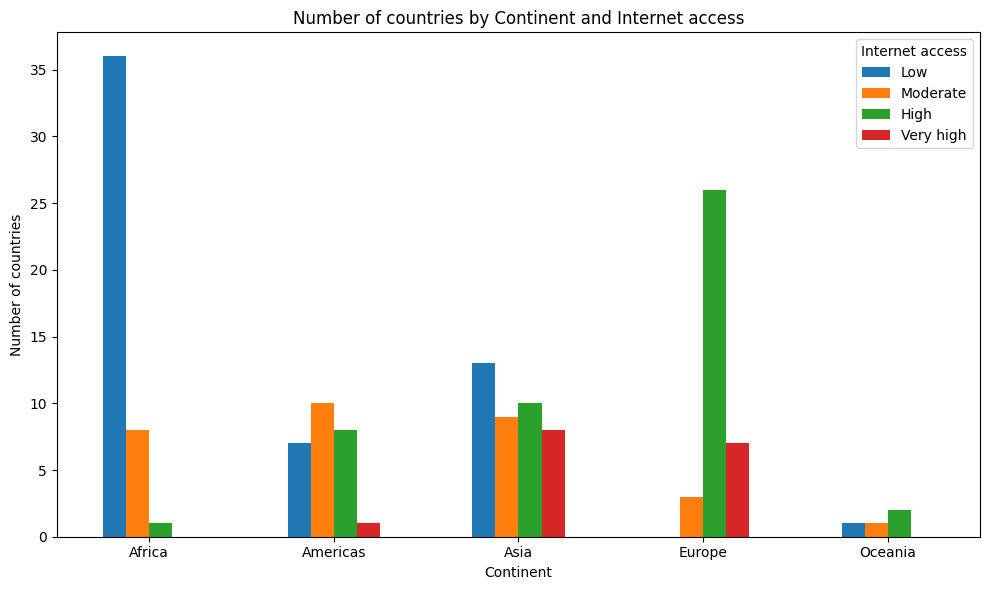

In [83]:
pt = country.pivot_table(
    values='Years',
    index='Continent',
    columns='Internet access',
    aggfunc=np.size,
    observed=False #obseerved=False to include all combinations of categories
)
pt.plot(kind='bar', figsize=(10, 6))
plt.title('Number of countries by Continent and Internet access')
plt.xlabel('Continent')
plt.ylabel('Number of countries')
plt.xticks(rotation=0)
plt.legend(title='Internet access')
plt.tight_layout()
plt.show()  


In [84]:
# np.size counts the number of entries

country.pivot_table(values='Years', index='Internet access', 
                    columns='Emissions range', aggfunc=np.size,observed=False)

Emissions range,Low,Moderate,High,Very high
Internet access,,,,
Low,52.0,3.0,2.0,NaN
Moderate,9.0,18.0,4.0,NaN
High,1.0,17.0,23.0,6.0
Very high,NaN,1.0,5.0,10.0


# Value = fertility

In [85]:
country.pivot_table(
    values='Fertility',
    index='Continent',
    columns='Internet access',
    aggfunc=np.mean,
    observed=False #obseerved=False to include all combinations of categories
)   


/tmp/ipykernel_13836/3702572265.py:1: FutureWarning: The provided callable <function mean at 0x7a88771e9300> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  country.pivot_table(


Internet access,Low,Moderate,High,Very high
Continent,,,,
Africa,4.503889,2.4625,2.250000,NaN
Americas,2.500000,2.1680,1.931250,1.560000
Asia,2.703846,2.2200,1.999000,1.830000
Europe,NaN,1.6200,1.587308,1.751429
Oceania,3.570000,2.4700,1.900000,NaN


In [86]:
# Categorical features are sorted in alphabetical order by default
country['Internet access'] = country['Internet access'].astype('category')

# cat.reorder_categories is useful for rearranging the order
# (ex: low to high)
country['Internet access'] = country['Internet access'].cat.reorder_categories(
    ['Low', 'Moderate', 'High', 'Very high']
)
# Display the number of countries in a pivot table of continent and
# internet access
country.pivot_table(values='Years', index='Continent', 
                    columns='Internet access', aggfunc=np.size,observed=False)


Internet access,Low,Moderate,High,Very high
Continent,,,,
Africa,36.0,8.0,1.0,NaN
Americas,7.0,10.0,8.0,1.0
Asia,13.0,9.0,10.0,8.0
Europe,NaN,3.0,26.0,7.0
Oceania,1.0,1.0,2.0,NaN


In [87]:
# Which 7 countries in the Americas have high Internet access?
#country[(country['Continent'] == 'Americas') & (country['Emissions range'] == 'Low') & (country['Internet access'] == 'High')]
# which 7 countries in the Americas have very high Internet access?
country[(country['Continent'] == 'Americas') &  (country['Internet access'] == 'Very high')]

,Country,Continent,Years,Internet access,Emissions range,Fertility,Emissions,Internet
26,Canada,Americas,13.3,Very high,Very high,1.56,15.3,94.6


In [88]:
# Display the average number of years of schooling
country.pivot_table(values='Years', index='Continent', columns='Internet access', 
                    aggfunc="mean",observed=False)

Internet access,Low,Moderate,High,Very high
Continent,,,,
Africa,4.836111,7.475000,9.500000,NaN
Americas,7.328571,9.220000,9.737500,13.300000
Asia,6.346154,9.566667,10.530000,10.100000
Europe,NaN,11.033333,11.588462,12.828571
Oceania,7.900000,10.800000,12.700000,NaN


## Groupby in pandas


In [89]:
# Display the average of each feature by continent

country.groupby(by=["Continent"]).mean(numeric_only=True)

,Years,Fertility,Emissions,Internet
Continent,,,,
Africa,5.408889,4.090889,1.127953,31.057778
Americas,9.026923,2.161154,3.309308,62.411538
Asia,8.867500,2.244000,7.431350,63.882500
Europe,11.783333,1.621944,6.716944,81.738889
Oceania,11.025000,2.460000,6.812750,68.725000


In [90]:
# Display the median of each feature by continent

country.groupby(by=["Continent"]).median(numeric_only=True)

,Years,Fertility,Emissions,Internet
Continent,,,,
Africa,5.20,4.410,0.434,25.00
Americas,8.70,2.130,2.260,63.40
Asia,9.35,2.020,3.925,67.15
Europe,12.05,1.605,5.905,81.30
Oceania,11.65,2.220,4.875,78.25


In [91]:
# Display the number of countries in the dataset
# for each continent

country.groupby(by=["Continent"]).size()

Continent
Africa      45
Americas    26
Asia        40
Europe      36
Oceania      4
dtype: int64

In [92]:
# Use describe on each feature

country.describe()

,Years,Fertility,Emissions,Internet
count,151.000000,151.000000,151.000000,151.000000
mean,8.616556,2.637550,4.656390,58.232450
std,3.165426,1.230491,5.625596,27.190164
min,1.500000,1.240000,0.046700,4.100000
25%,6.250000,1.720000,0.794500,34.450000
50%,9.100000,2.120000,2.640000,64.100000
75%,11.300000,3.325000,6.425000,80.900000
max,14.200000,5.880000,38.000000,99.700000


In [93]:
# Use describe on each feature for each continent

country.groupby(by=["Continent"]).describe()

Years                                                         \
          count       mean       std  min     25%    50%     75%   max   
Continent                                                                
Africa     45.0   5.408889  2.147496  1.5   3.600   5.20   6.800  10.1   
Americas   26.0   9.026923  1.981829  5.3   7.925   8.70  10.125  13.5   
Asia       40.0   8.867500  2.688474  3.1   7.175   9.35  10.825  13.0   
Europe     36.0  11.783333  1.199405  9.2  11.250  12.05  12.425  14.2   
Oceania     4.0  11.025000  2.273580  7.9  10.075  11.65  12.600  12.9   

          Fertility            ... Emissions       Internet             \
              count      mean  ...       75%   max    count       mean   
Continent                      ...                                       
Africa         45.0  4.090889  ...    1.1600   8.1     45.0  31.057778   
Americas       26.0  2.161154  ...    3.0225  16.6     26.0  62.411538   
Asia           40.0  2.244000  ...    8.9450  38.0     40.0  63.882500   
Europe         36.0  1.621944  ...    8.3625  15.9     36.0  81.738889   
Oceania         4.0  2.460000  ...    9.7300  16.9      4.0  68.725000   

                                                         
                 std   min     25%    50%     75%   max  
Continent                                                
Africa     19.035893   4.1  15.800  25.00  43.000  70.1  
Americas   17.080523  32.5  50.800  63.40  74.475  94.6  
Asia       26.208081  15.3  43.900  67.15  84.675  99.7  
Europe      9.654704  62.6  74.625  81.30  88.975  99.0  
Oceania    27.771853  29.4  59.025  78.25  87.950  89.0  

[5 rows x 32 columns]

In [94]:
# Display a subset of the data above using .agg()

country.groupby("Continent").agg(
    min_Emissions=pd.NamedAgg(column="Emissions", aggfunc="min"),
    max_Emissions=pd.NamedAgg(column="Emissions", aggfunc="max"),
    mean_Emissions=pd.NamedAgg(column="Emissions", aggfunc="mean"),
)

,min_Emissions,max_Emissions,mean_Emissions
Continent,,,
Africa,0.0467,8.1,1.127953
Americas,0.2700,16.6,3.309308
Asia,0.2540,38.0,7.431350
Europe,1.5900,15.9,6.716944
Oceania,0.6010,16.9,6.812750


## CHALLENGE ACTIVITY| 5.2.2: Manipulating data using pandas

**This dataset contains information on credit card customers, such as the customer average credit limit, number of credit cards, number of physical visits to the bank, and number of visits to the bank's website.**
* **Use a pandas method to create a frequency table for <I>Total_visits_bank</I>.**
**Assign the table to <I>freqTable.</I>.**

**The code provided contains all imports, loads the dataset, and prints the table.**

In [95]:
# Import packages and functions
import pandas as pd

# Load the dataset
df = pd.read_csv('credit_card.csv')

df.columns

# Create a frequency table for Total_visits_bank
freqTable = df['Total_visits_bank'].value_counts().sort_index()

# Display frequency table
print(freqTable)

Total_visits_bank
0     7
1    10
2     8
3     8
4     3
5    14
Name: count, dtype: int64


**This dataset contains information on credit card customers, such as the customer average credit limit, number of credit cards, number of physical visits to the bank, and number of visits to the bank website.**

* **Use a pandas method to calculate a contingency table with Total_visits_bank on the rows, Total_Credit_Cards on the columns, and Customer Key as the values.**
**Assign the table to contingencyTable.**

**The code provided contains all imports, loads the dataset, and prints the resulting table.**

In [96]:

# Create a contingency table for Total_visits_bank and Total_Credit_Cards
# Your code goes here
raw_df = pd.read_csv("credit_cards.csv")
# print(raw_df)

raw_df = raw_df.merge(df , how= 'outer')
raw_df

contingencyTable = raw_df.pivot_table(index='Total_visits_bank',columns='Total_Credit_Cards',values='Customer Key', aggfunc=np.size, observed=False)
# raw_df = df['Customer Key','Total_visits_bank']
# raw_df.pi
# # raw_df.pivot_table(values=,index = ['Total_vis'])

# Display contingency table
print(contingencyTable)

Total_Credit_Cards     1     2      3      4      5      6      7     8     10
Total_visits_bank                                                             
0.0                  59.0  64.0  106.0  453.0    NaN    NaN    NaN   NaN   NaN
1.0                 118.0   NaN  106.0  453.0    NaN    NaN  101.0  11.0  19.0
2.0                 118.0  64.0   53.0  302.0    NaN  117.0  101.0   NaN   NaN
3.0                   NaN   NaN    NaN  151.0   74.0  585.0  101.0   NaN   NaN
4.0                   NaN   NaN    NaN    NaN    NaN  234.0  101.0   NaN   NaN
5.0                   NaN   NaN    NaN  604.0  148.0  819.0  101.0   NaN   NaN


# Successfully Solved